# Figure 8 — The position head: raw vs head-corrected agreement

Same offset measurement as Fig 7, now **before vs after** the per-object latent position head.
**Left:** all-detection offset clouds, solid = raw, dashed = head-corrected (contour encloses 50%).
**Right:** median radial offset vs S/N, raw vs head \u2014 the head flattens the FWHM/SNR
degradation, bringing faint sources down to the bright-source floor.

In [1]:
import sys
from pathlib import Path
import numpy as np
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root(); NB=Path.cwd()
OUT=REPO/'paper'/'figures'/'fig8_head_correction.png'
CANDIDATES=[
    REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_dedup.npz',
    REPO/'models/checkpoints/latent_position_v10_vispeak/anchors_centernet_v10_vispeak_dedup.npz',
]
CACHE=next((p for p in CANDIDATES if p.exists()),None); assert CACHE
print('anchor cache:',CACHE.relative_to(REPO),'| Q1:','q1' in CACHE.name)
BRIGHT_SNR=30; ENCLOSED_FRAC=0.50; DROP_BANDS=['u','y']; VIEW=90; BINS=64; SMOOTH=2.0


anchor cache: models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_dedup.npz | Q1: True


saved paper/figures/fig8_head_correction.png


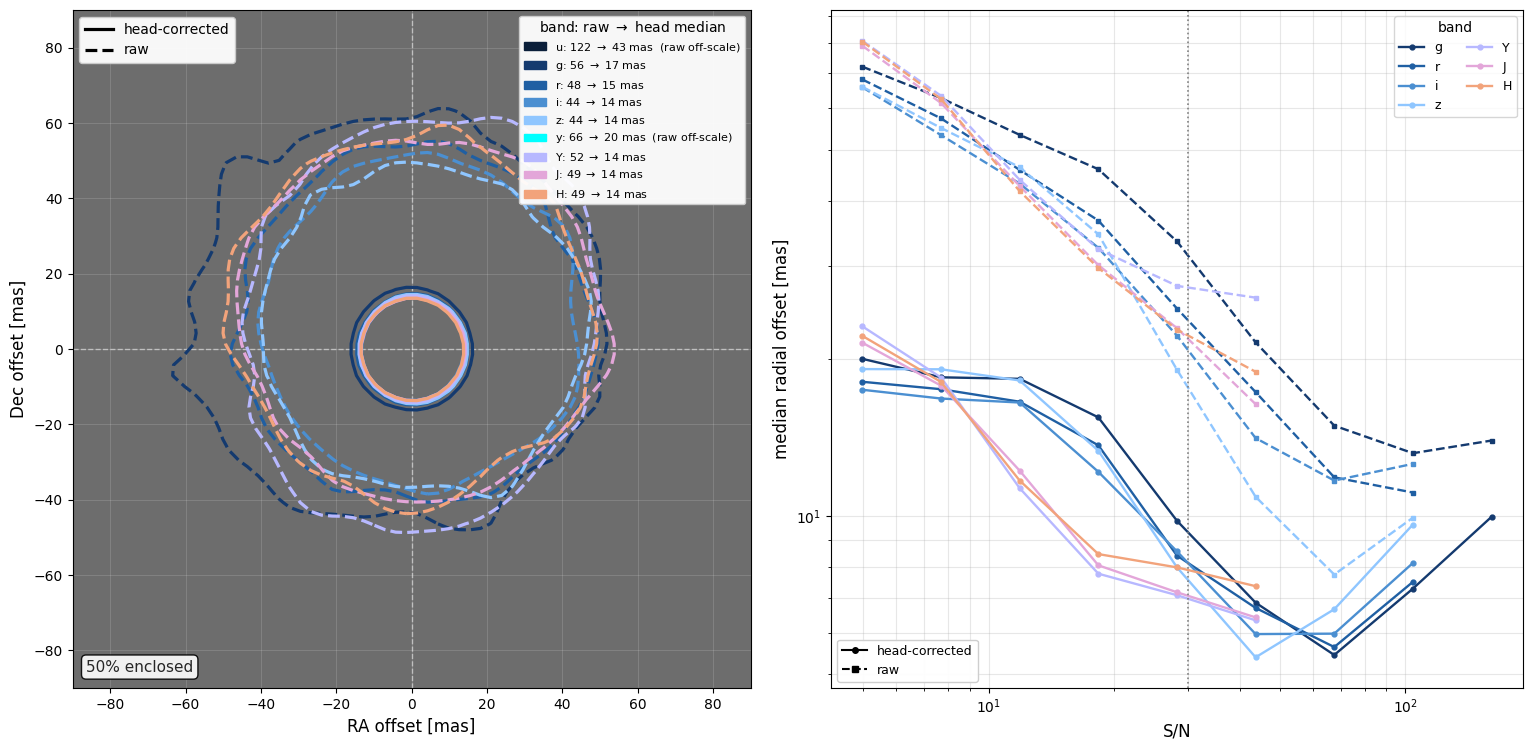

In [2]:
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
d=np.load(CACHE,allow_pickle=True)
BAND_DEF=[('u','#0B1F3A'),('g','#143A6F'),('r','#1F5FA3'),('i','#4B8FD1'),('z','#8FC6FF'),
          ('y','#00FFFF'),('nisp_Y','#B7B8FF'),('nisp_J','#E3A6D9'),('nisp_H','#F2A37B')]
LAB={'nisp_Y':'Y','nisp_J':'J','nisp_H':'H'}; SKIP=DROP_BANDS
def off(b,kind): return np.asarray(d[f'{b}_{kind}'])*1000.0
def snr(b): return np.asarray(d[f'{b}_snr'])
def frac_contour(ax,xy,col,ls,frac=ENCLOSED_FRAC):
    dra,ddec=xy[:,0],xy[:,1]
    if len(dra)<80: return
    H,xe,ye=np.histogram2d(dra,ddec,bins=BINS,range=[[-VIEW,VIEW],[-VIEW,VIEW]])
    Hs=gaussian_filter(H.T,SMOOTH)
    ix=np.clip(np.digitize(dra,xe)-1,0,BINS-1); iy=np.clip(np.digitize(ddec,ye)-1,0,BINS-1)
    lvl=np.quantile(Hs[iy,ix],1-frac)
    xc=0.5*(xe[:-1]+xe[1:]);yc=0.5*(ye[:-1]+ye[1:]);X,Y=np.meshgrid(xc,yc)
    ax.contour(X,Y,Hs,levels=[lvl],colors=col,linewidths=2.3,linestyles=ls)
fig,(axL,axR)=plt.subplots(1,2,figsize=(15.5,7.6))
axL.set_facecolor('#6D6D6D'); axL.set_xlim(-VIEW,VIEW); axL.set_ylim(-VIEW,VIEW); axL.set_aspect('equal')
axL.grid(True,alpha=0.2,color='white',lw=0.5); axL.axhline(0,color='white',ls='--',alpha=0.5,lw=1); axL.axvline(0,color='white',ls='--',alpha=0.5,lw=1)
bh=[]
for b,col in BAND_DEF:
    ra=off(b,'raw'); hd=off(b,'head_resid')
    mr=np.median(np.hypot(*ra.T)); mh=np.median(np.hypot(*hd.T))
    if b not in SKIP:
        frac_contour(axL,ra,col,'dashed'); frac_contour(axL,hd,col,'solid')
        bh.append(mpatches.Patch(color=col,label=f"{LAB.get(b,b)}: {mr:.0f} $\\to$ {mh:.0f} mas"))
    else:
        bh.append(mpatches.Patch(color=col,label=f"{LAB.get(b,b)}: {mr:.0f} $\\to$ {mh:.0f} mas  (raw off-scale)"))
axL.set_xlabel('RA offset [mas]',fontsize=12); axL.set_ylabel('Dec offset [mas]',fontsize=12)
sh=[Line2D([0],[0],color='k',ls='solid',lw=2.3,label='head-corrected'),
    Line2D([0],[0],color='k',ls='--',lw=2.3,label='raw')]
l1=axL.legend(handles=sh,loc='upper left',fontsize=10,framealpha=0.95,facecolor='white'); axL.add_artist(l1)
axL.legend(handles=bh,loc='upper right',fontsize=8.0,framealpha=0.95,facecolor='white',title='band: raw $\\to$ head median')
axL.text(0.02,0.02,f'{int(ENCLOSED_FRAC*100)}% enclosed',transform=axL.transAxes,fontsize=11,color='0.15',va='bottom',bbox=dict(boxstyle='round',facecolor='white',alpha=0.9))
edges=np.logspace(np.log10(4),np.log10(200),10); cen=np.sqrt(edges[:-1]*edges[1:])
for b,col in BAND_DEF:
    if b in SKIP: continue
    s=snr(b)
    for kind,ls,mk in [('raw','--','s'),('head_resid','solid','o')]:
        rad=np.hypot(*off(b,kind).T)
        yv=[np.median(rad[(s>=lo)&(s<hi)]) if ((s>=lo)&(s<hi)).sum()>=40 else np.nan for lo,hi in zip(edges[:-1],edges[1:])]
        axR.plot(cen,yv,ls=ls,marker=mk,color=col,ms=3.5,lw=1.7,label=LAB.get(b,b) if kind=='head_resid' else None)
axR.set_xscale('log'); axR.set_yscale('log')
axR.set_xlabel('S/N',fontsize=12); axR.set_ylabel('median radial offset [mas]',fontsize=12)
axR.axvline(BRIGHT_SNR,color='0.5',ls=':',lw=1.2); axR.grid(True,alpha=0.3,which='both')
h1=[Line2D([0],[0],color='k',ls='solid',marker='o',ms=4,label='head-corrected'),
    Line2D([0],[0],color='k',ls='--',marker='s',ms=4,label='raw')]
leg=axR.legend(handles=h1,loc='lower left',fontsize=9,framealpha=0.95); axR.add_artist(leg)
axR.legend(fontsize=9,ncol=2,title='band',loc='upper right')
plt.tight_layout(); OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=200,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()
